In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print("\nFraud vs Normal:")
print(df['Class'].value_counts())
print("\nFraud %:")
print(df['Class'].value_counts(normalize=True) * 100)

Shape: (284807, 31)

Fraud vs Normal:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


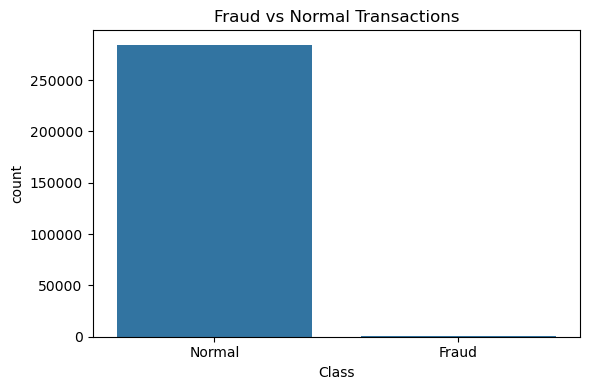

Chart saved ✅


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Normal Transactions')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.tight_layout()
plt.savefig('class_imbalance.png')
plt.show()
print("Chart saved ✅")

In [3]:
X = df.drop('Class',axis =1)
y= df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fraud cases:", y.sum())

X shape: (284807, 30)
y shape: (284807,)
Fraud cases: 492


In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test , y_train,y_test=train_test_split(X,y ,test_size=0.2 ,random_state=42,stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (227845, 30)
Test size: (56962, 30)


In [10]:
X_train_original = X_train.copy()
y_train_original = y_train.copy()

print("Original train copy saved ✅")
print("Shape:", X_train_original.shape)

Original train copy saved ✅
Shape: (227845, 30)


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [8]:
# fraud transactions nikalo
fraud_tsx = X[y == 1].copy()
# fraud_tsx['Class'] = 1

fraud_tsx.to_csv('fraud_tsx.csv', index=False)
print(f"Fraud transactions: {len(fraud_tsx)}")

Fraud transactions: 492


In [9]:
fraud_tsx

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,-0.171608,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,0.009061,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00
